# Using ROCS Scorer in DrugEx RNN

how to integrate the ROCS scorer into a DrugEx RNN workflow

- Configuring both CPU‑fallback (ez_rocs) and GPU‑accelerated (fastrocs) scorers with an .sq query  
- Scoring and visualizing example SMILES  
- Building a multi‑objective environment combining ROCS similarity and synthetic‑accessibility  
- Fine‑tuning and reinforcement‑learning of an RNN generator  
- Evaluating generated molecules (desired count, average scores, top hits) and comparing GPU vs. CPU performance  

## Prerequisites

To run this notebook, you need:
1. The DrugEx package installed
2. OpenEye toolkit with a valid license
3. A ROCS query file (.sq format)

## 1. Setting Up ROCS Scorer



In [1]:
from drugex.training.scorers.ez_rocs import RocsScorer
from drugex.training.scorers.fastrocs import OpenEyeScorer
from drugex.training.scorers.fastrocs_paralell_v2 import OpenEyeScorer as OpenEyeScorer_parallel
import os
from rdkit.Chem import PandasTools
import pandas as pd
import matplotlib.pyplot as plt

# Path to your ROCS query file (.sq format)
sq_file = 'model3-4_v1.sq'

# Initialize the ROCS scorer
ez_rocs_scorer = RocsScorer(
    query_file=sq_file,                # Path to the .sq model file
    experiment_name="ccr2_experiment", # Name for temporary files
    score_type="TanimotoCombo",        # Type of score to extract (TanimotoCombo, ShapeTanimoto, or ColorTanimoto)
    use_gpu=True,
    max_isomers=4,
    max_rot_bonds=15,
    max_heavy_atoms=45,
    max_conformers=200,   # number of conformers to generate per molecule
    cpu_processes=1   # this is used when use_gpu is False
)

fastrocs_scorer = OpenEyeScorer(
    sq_model_path=sq_file,
    use_gpu=True,           # when use_gpu is False, will all available CPU -2 !!!! This can cause OOM error
    max_isomers=4,
    max_rot_bonds=15,
    max_heavy_atoms=45,
    max_conformers=200,   # same for confs
)

fastrocs_parallel_scorer = OpenEyeScorer_parallel(
    sq_model_path=sq_file,
    use_gpu=True,           # when use_gpu is False, will all available CPU -2 !!!! This can cause OOM error
    max_isomers=4,
    max_rot_bonds=15,
    max_heavy_atoms=45,
    max_conformers=200,   # same for confs
)

OpenEye memory pool initialized in ez_rocs module
ROCS scorer initialized using GPU mode
FastROCS GPU mode   : ON  (single process)
CPUs: 32, CPU workers: 6
GPUs: 1, GPU mode: True


In [2]:
from openeye import oefastrocs
print("GPU ready?", oefastrocs.OEFastROCSIsGPUReady())

GPU ready? True


### Key Parameters of RocsScorer

The `RocsScorer` class accepts several parameters to customize its behavior:

- `sq_model_path`: Path to the ROCS query file (.sq format)
- `experiment_name`: Name for temporary files created during scoring
- `score_type`: Type of score to return. Options include:
  - `"TanimotoCombo"`: Combined shape and color score (default)
  - `"ShapeTanimoto"`: Shape-only similarity score
  - `"ColorTanimoto"`: Color (chemical features) similarity score
- `use_gpu`: Whether to use GPU acceleration (default: False)
- `max_isomers`: Maximum number of isomers to enumerate per molecule (default: 4)
- `max_rot_bonds`: Maximum number of rotatable bonds to consider (default: 10)
- `max_heavy_atoms`: Maximum number of heavy atoms to process (default: 30)
- `cpu_processes`: Number of CPU processes to use if not using GPU (default: 1)

## 2. Basic Usage: Scoring Molecules

Let's score some example molecules to see how the ROCS scorer works.

In [3]:
# Example SMILES strings to score

test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]
# Get scores for the molecules
scores = fastrocs_scorer.getScores(test_smiles)

# Display the scores
for smi, score in zip(test_smiles, scores):
    print(f"SMILES: {smi}\nfastrocs_Score: {score:.4f}\n")

# Create a DataFrame for easier visualization
results_df = pd.DataFrame({
    'SMILES': test_smiles,
    'fastrocs_Score': scores
})
results_df

Omega GPU mode enabled for conformer generation
FastROCS GPU mode enabled for shape queries
Preparing 284 molecules for GPU processing...
SMILES: O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1
fastrocs_Score: 0.4649

SMILES: CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S
fastrocs_Score: 0.5735



,SMILES,fastrocs_Score
0,O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1c...,0.464928
1,CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2...,0.573508


In [4]:
# Example SMILES strings to score

test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]
# Get scores for the molecules
scores = ez_rocs_scorer.getScores(test_smiles)

# Display the scores
for smi, score in zip(test_smiles, scores):
    print(f"SMILES: {smi}\nez_rocs Score: {score:.4f}\n")

# Create a DataFrame for easier visualization
results_df = pd.DataFrame({
    'SMILES': test_smiles,
    'ez_rocs_Score': scores
})
results_df

SMILES: O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1
ez_rocs Score: 0.4646

SMILES: CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S
ez_rocs Score: 0.5739



,SMILES,ez_rocs_Score
0,O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1c...,0.464615
1,CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2...,0.573860


### Visualizing the Results



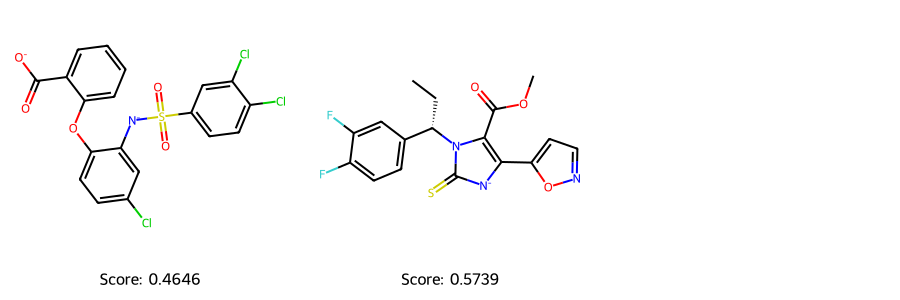

In [5]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert SMILES to RDKit molecules
mols = [Chem.MolFromSmiles(smi) for smi in test_smiles]

# Create labels with scores
legends = [f"Score: {score:.4f}" for score in scores]

# Display molecules with their scores
img = Draw.MolsToGridImage(mols, molsPerRow=3, legends=legends, subImgSize=(300, 300))
img

## 3. Integration with DrugEx RNN



In [6]:
# Import additional required modules
from drugex.training.environment import DrugExEnvironment
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.training.scorers.properties import Property
from drugex.data.corpus.vocabulary import VocSmiles
from drugex.training.generators import SequenceRNN
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor

# Path to pretrained model (adjust as needed)
GPUS = [0]  # Use GPU 0
MODELS_PATH = "../data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT"

voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)

# Load pretrained model
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')


### Creating a Multi-Objective Environment


1. ROCS similarity (higher is better)
2. Synthetic accessibility (lower is better, using the SA score)

# Here will be needed to tweak the clipping correctly, set too low for now, 


## two types of scorers ez_rocs is a base and fastrocs is gpu optimized "hopefully"

## maybe would be beneficial to think about the setting for filtering bad molecules or those you do not want so will not spend time do shape-match them 

In [7]:
# Synthetic Accessibility Scorer (1-10 scale, lower = better)
sa_scorer = Property("SA")
sa_scorer.setModifier(SmoothClippedScore(lower_x=5, upper_x=3))  # Matches your graph

# ROCS Combo Scorer (0-2 scale, higher = better)
# rocs_scorer = Property("ROCS")
# rocs_scorer.setModifier(SmoothClippedScore(lower_x=0.5, upper_x=1.5))  # Prioritize scores 0.5-1.5

# Calculate normalized threshold for desired real ROCS ≥ 1.0
# Formula: (real_score - lower_x) / (upper_x - lower_x)
rocs_threshold = (1.0 - 0.5) / (1.5 - 0.5)  # = 0.5

# Thresholds in normalized scores (0-1)
thresholds = [
    0.35,    # ROCS: Real score ≥1.0 → normalized 0.5
    0.1     # SA: Real score ≤3.9 → normalized 0.3
]


In [8]:
# --------------------------
# Multi-Objective Optimization
# --------------------------
scorer_ez = [ez_rocs_scorer, sa_scorer]
fastrocs_scorer = [fastrocs_scorer, sa_scorer]
fastrocs_parallel_scorer = [fastrocs_parallel_scorer, sa_scorer]


# **Choose scorer:**

## we will use the robust stable version of the scorer fastrocs import OpenEyeScorer


In [9]:
# Create environment with Pareto optimization
env = DrugExEnvironment(
    scorers=fastrocs_scorer,  # fastrocs_scorer , scorer_ez, fastrocs_parallel_scorer
    thresholds=thresholds,
    reward_scheme=ParetoCrowdingDistance()  # Multi-objective optimization scheme
)

# Finetuning

In [10]:
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter, Standardization
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor
import multiprocessing as mp
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.datasets import SmilesDataSet


CPU_COUNT     = max(1, mp.cpu_count() - 2)  
MODEL_DIR_RL = "./rocs_rl_ccr"
if not os.path.exists(MODEL_DIR_RL):
    os.makedirs(MODEL_DIR_RL)
    
    
print(f"Fine-tuning device: {'GPU' if GPUS else 'CPU'} (GPUS: {GPUS})")

voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')
data_path = "CCR_HUMAN_AL.tsv"
print(f"Loading fine-tuning data from {data_path}")
df = pd.read_csv(data_path, sep='\t')



Fine-tuning device: GPU (GPUS: [0])
Loading fine-tuning data from CCR_HUMAN_AL.tsv


In [11]:
if 'SMILES' not in df.columns:
    print(f"ERROR: No 'SMILES' column found in {data_path}")



X_train = df['SMILES'].values
model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
model.load_state_dict(pretrained.state_dict())

CHUNK_SIZE = 1024
BATCH_SIZE = 256
FT_EPOCHS = 30

standardizer = Standardization(n_proc=CPU_COUNT, chunk_size=CHUNK_SIZE)
valid_smiles = standardizer.apply(X_train)
print(f"Found {len(valid_smiles)} valid SMILES strings for training")
os.makedirs(MODEL_DIR_RL, exist_ok=True)
corpus_file = os.path.join(MODEL_DIR_RL, "corpus.tsv")
voc_file = os.path.join(MODEL_DIR_RL, "model.vocab")
encoder = CorpusEncoder(
    SequenceCorpus,
    {'vocabulary': voc, 'update_voc': False, 'throw': True},
    n_proc=CPU_COUNT,
    chunk_size=CHUNK_SIZE
)

Standardizing molecules (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Found 1021 valid SMILES strings for training


In [12]:
data_collector = SmilesDataSet(corpus_file, rewrite=True)
encoder.apply(valid_smiles, collector=data_collector)
voc.toFile(voc_file)

print(f"Saved vocabulary to {voc_file}")
splitter = RandomTrainTestSplitter(0.05, 1e4)
train, test = splitter(data_collector.getData())
for data, name in zip([train, test], ['train', 'test']):
    pd.DataFrame(data, columns=data_collector.getColumns()).to_csv(
        os.path.join(MODEL_DIR_RL, f'ligand_{name}.tsv'),
        header=True, index=False, sep='\t'
    )

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Molecule does not meet min/max words requirements (min: 10, max: 100). Words found: {'(', '1', '3', 'O', ')', '2', '=', 'S', 'L', 'N', 'c', 'F', 'C', 'EOS'} (occurrence count: 102). It will be ignored.


Saved vocabulary to ./rocs_rl_ccr/model.vocab


## Uncomment for finetuning

In [13]:
data_set_train = SmilesDataSet(os.path.join(MODEL_DIR_RL, 'ligand_train.tsv'), voc=voc)
train_loader = data_set_train.asDataLoader(batch_size=BATCH_SIZE)
data_set_test = SmilesDataSet(os.path.join(MODEL_DIR_RL, 'ligand_test.tsv'), voc=voc)
valid_loader = data_set_test.asDataLoader(batch_size=BATCH_SIZE)
print(f"Fine-tuning model for {FT_EPOCHS} epochs")

model.fit(train_loader, valid_loader, epochs=FT_EPOCHS,
             monitor=FileMonitor(
                 f"{MODEL_DIR_RL}/finetune", 
                 save_smiles=True,
                 reset_directory=False
                 ))

os.makedirs(MODEL_DIR_RL, exist_ok=True)
model_path = f'{MODEL_DIR_RL}/finetune.pkg'
voc.toFile(f'{MODEL_DIR_RL}/finetune.vocab')
print(f"Model saved to {model_path}")
print("Fine-tuning completed successfully")


Fine-tuning model for 30 epochs


Fitting model:   0%|          | 0/30 [00:00<?, ?it/s]

Model saved to ./rocs_rl_ccr/finetune.pkg
Fine-tuning completed successfully


### Setting Up Reinforcement Learning



In [14]:
try:
    vocab_path = f'{MODEL_DIR_RL}/finetune.vocab'
    voc = VocSmiles.fromFile(vocab_path, encode_frags=False)
except FileNotFoundError:
    print("Finetuned vocabulary not found, using pretrained vocabulary instead")
    voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)

try:
    finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
    finetuned.loadStatesFromFile(f'{MODEL_DIR_RL}/finetune.pkg')
except FileNotFoundError:
    print("Finetuned model not found, using pretrained model instead")
    finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
    finetuned.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')


In [15]:
explorer = SequenceExplorer(
    agent=finetuned,
    env=env,
    mutate=pretrained,
    epsilon=0.1,
    batch_size=256,
    n_samples=4000,
    use_gpus=GPUS
)

# Set up output directory for training logs
os.makedirs(MODEL_DIR_RL, exist_ok=True)

# Configure monitor to track progress
monitor = FileMonitor(
    f"{MODEL_DIR_RL}/rocs_agent", 
    save_smiles=True,          # Save generated SMILES
    reset_directory=True       # Clear previous results
)

Removing rocs_agent_fit.log from ./rocs_rl_ccr
Removing rocs_agent_fit.tsv from ./rocs_rl_ccr
Removing rocs_agent_smiles.tsv from ./rocs_rl_ccr
Removing rocs_agent.pkg from ./rocs_rl_ccr


### Training the Model


In [16]:
# Run reinforcement learning (in practice, use more epochs, e.g., 30-100)
explorer.fit(monitor=monitor, epochs=50, patience=10)

# Load training progress
training_df = pd.read_csv(f"{MODEL_DIR_RL}/rocs_agent_fit.tsv", sep='\t')


Fitting SMILES RNN explorer:   0%|          | 0/50 [00:00<?, ?it/s]

Preparing 1015 molecules for GPU processing...
Preparing 1278 molecules for GPU processing...
Preparing 209 molecules for GPU processing...
Preparing 405 molecules for GPU processing...
Preparing 1814 molecules for GPU processing...
Preparing 1134 molecules for GPU processing...
Preparing 363 molecules for GPU processing...
Preparing 1809 molecules for GPU processing...
Preparing 1173 molecules for GPU processing...
Preparing 290 molecules for GPU processing...
Preparing 1303 molecules for GPU processing...
Preparing 1511 molecules for GPU processing...
Preparing 978 molecules for GPU processing...
Preparing 1296 molecules for GPU processing...
Preparing 1198 molecules for GPU processing...
Preparing 3697 molecules for GPU processing...
Preparing 265 molecules for GPU processing...
Preparing 529 molecules for GPU processing...
Preparing 1045 molecules for GPU processing...
Preparing 1624 molecules for GPU processing...
Preparing 720 molecules for GPU processing...
Preparing 1228 molecu

Calculating policy gradient...:   0%|          | 0/16 [00:00<?, ?it/s]

Preparing 4445 molecules for GPU processing...
Preparing 4394 molecules for GPU processing...
Preparing 4253 molecules for GPU processing...
Preparing 3361 molecules for GPU processing...
Preparing 4138 molecules for GPU processing...
Preparing 5017 molecules for GPU processing...
Preparing 4884 molecules for GPU processing...
Preparing 3331 molecules for GPU processing...
Preparing 2950 molecules for GPU processing...
Preparing 5853 molecules for GPU processing...
Preparing 5136 molecules for GPU processing...
Preparing 4661 molecules for GPU processing...
Preparing 4065 molecules for GPU processing...
Preparing 1664 molecules for GPU processing...
Preparing 4835 molecules for GPU processing...
Preparing 6348 molecules for GPU processing...
Preparing 4931 molecules for GPU processing...
Preparing 5061 molecules for GPU processing...
Preparing 3061 molecules for GPU processing...
Preparing 3760 molecules for GPU processing...
Preparing 3081 molecules for GPU processing...
Preparing 396

Calculating policy gradient...:   0%|          | 0/16 [00:00<?, ?it/s]

...

Calculating policy gradient...:   0%|          | 0/15 [00:00<?, ?it/s]

Preparing 3094 molecules for GPU processing...
Preparing 2444 molecules for GPU processing...
Preparing 2730 molecules for GPU processing...
Preparing 2979 molecules for GPU processing...
Preparing 2795 molecules for GPU processing...
Preparing 3718 molecules for GPU processing...
Preparing 2834 molecules for GPU processing...
Preparing 3574 molecules for GPU processing...
Preparing 2531 molecules for GPU processing...
Preparing 3195 molecules for GPU processing...
Preparing 3146 molecules for GPU processing...
Preparing 2718 molecules for GPU processing...
Preparing 3121 molecules for GPU processing...
Preparing 1070 molecules for GPU processing...
Preparing 2765 molecules for GPU processing...
Preparing 2564 molecules for GPU processing...
Preparing 2897 molecules for GPU processing...
Preparing 4203 molecules for GPU processing...
Preparing 3147 molecules for GPU processing...
Preparing 3472 molecules for GPU processing...
Preparing 3118 molecules for GPU processing...
Preparing 368

Calculating policy gradient...:   0%|          | 0/15 [00:00<?, ?it/s]

Preparing 2751 molecules for GPU processing...
Preparing 3538 molecules for GPU processing...
Preparing 3637 molecules for GPU processing...
Preparing 3213 molecules for GPU processing...
Preparing 2662 molecules for GPU processing...
Preparing 2666 molecules for GPU processing...
Preparing 4209 molecules for GPU processing...
Preparing 3018 molecules for GPU processing...
Preparing 3212 molecules for GPU processing...
Preparing 2724 molecules for GPU processing...
Preparing 4195 molecules for GPU processing...
Preparing 3039 molecules for GPU processing...
Preparing 3871 molecules for GPU processing...
Preparing 1063 molecules for GPU processing...


,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.862,0.840,0.365,0.610,0.535,0.015,1
1,2,0.915,0.910,0.372,0.625,0.545,0.094,2
2,3,0.900,0.892,0.350,0.632,0.550,0.104,2
3,4,0.970,0.970,0.370,0.636,0.554,0.078,2
4,5,0.955,0.952,0.382,0.640,0.558,0.089,5
5,6,0.955,0.952,0.385,0.644,0.558,0.076,6
6,7,0.932,0.932,0.398,0.647,0.565,0.089,7
7,8,0.965,0.955,0.388,0.645,0.561,0.091,7
8,9,0.968,0.955,0.415,0.647,0.562,0.100,9
9,10,0.955,0.950,0.425,0.652,0.568,0.077,10


In [20]:
training_df.head(50)

,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.862,0.840,0.365,0.610,0.535,0.015,1
1,2,0.915,0.910,0.372,0.625,0.545,0.094,2
2,3,0.900,0.892,0.350,0.632,0.550,0.104,2
3,4,0.970,0.970,0.370,0.636,0.554,0.078,2
4,5,0.955,0.952,0.382,0.640,0.558,0.089,5
5,6,0.955,0.952,0.385,0.644,0.558,0.076,6
6,7,0.932,0.932,0.398,0.647,0.565,0.089,7
7,8,0.965,0.955,0.388,0.645,0.561,0.091,7
8,9,0.968,0.955,0.415,0.647,0.562,0.100,9
9,10,0.955,0.950,0.425,0.652,0.568,0.077,10


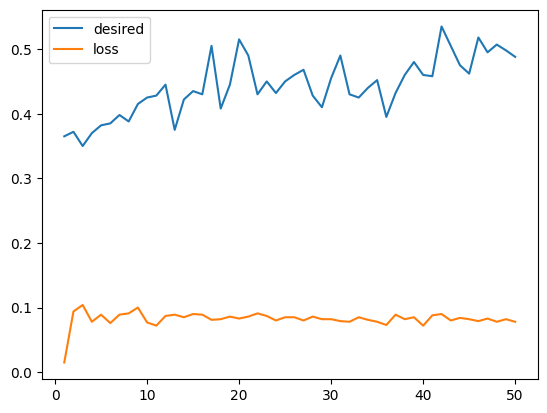

In [19]:
# linear plot of the training progress
plt.plot(training_df['Epoch'], training_df['desired_ratio'], label='desired')
plt.plot(training_df['Epoch'], training_df['loss_train'], label='loss')
plt.legend()
plt.show()


Generating molecules:   0%|          | 0/100 [00:00<?, ?it/s]

Preparing 3265 molecules for GPU processing...
Preparing 3928 molecules for GPU processing...
Preparing 3145 molecules for GPU processing...
Preparing 1255 molecules for GPU processing...
Generated 100 molecules
Desirable molecules: 52 (52.0%)
Average ROCS score: 0.3479
Average SA score: 0.9703


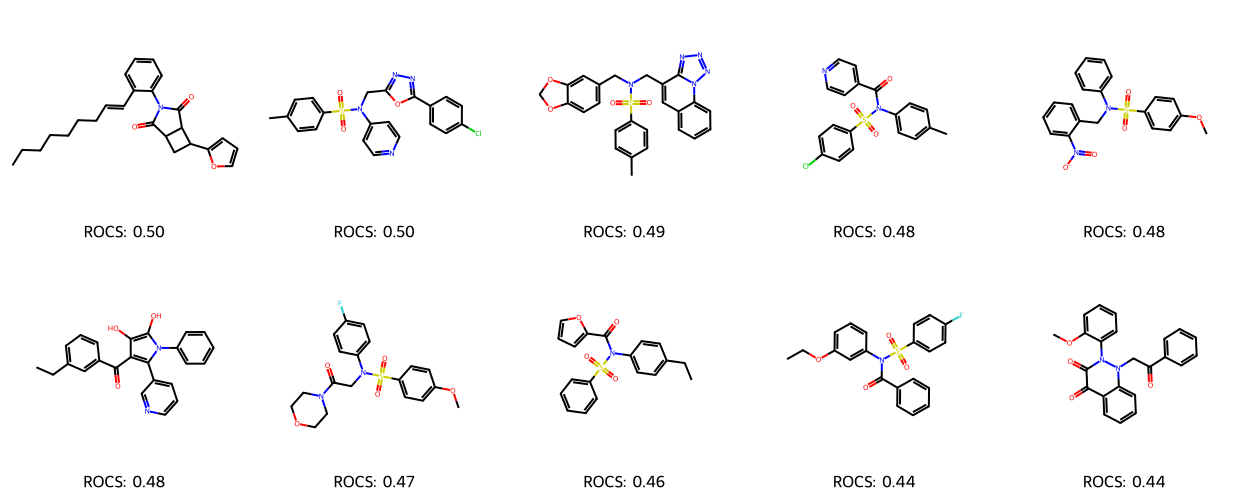

In [18]:
# Load the trained model
optimized_model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
optimized_model.loadStatesFromFile(f"{MODEL_DIR_RL}/rocs_agent.pkg")

# Generate molecules
generated = optimized_model.generate(num_samples=100)
generated_smiles = generated.SMILES.tolist()

# Score the generated molecules
scores = env.getScores(generated_smiles)
scores_df = pd.DataFrame(scores)

# Display summary statistics
print(f"Generated {len(generated_smiles)} molecules")
print(f"Desirable molecules: {scores_df['Desired'].sum()} ({scores_df['Desired'].mean()*100:.1f}%)")
print(f"Average ROCS score: {scores_df['ROCS'].mean():.4f}")
print(f"Average SA score: {scores_df['SA'].mean():.4f}")

# Show top 10 molecules by ROCS score
top_by_rocs = scores_df.sort_values('ROCS', ascending=False).head(10)
top_indices = top_by_rocs.index.tolist()
top_smiles = [generated_smiles[i] for i in top_indices]
top_scores = top_by_rocs['ROCS'].tolist()

# Convert to RDKit molecules and display
top_mols = [Chem.MolFromSmiles(smi) for smi in top_smiles]
legends = [f"ROCS: {score:.2f}" for score in top_scores]
img = Draw.MolsToGridImage(top_mols, molsPerRow=5, legends=legends, subImgSize=(250, 250))
img




Some key steps were:

1. Setting up the ROCS scorer with an appropriate shape query (.sq file)
2. Scoring molecules to evaluate their 3D shape similarity
3. Integrating the scorer into a DrugEx, finetuning and reinforcement learning pipeline
4. Training a model to generate molecules with high shape similarity
5. Evaluating the results and considering performance optimizations

